In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.data import get_sql_data
from src.cleaning import clean_data
from src.feature_transformation import Transformer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
SEED = 123

Fetching and cleaning the data.

In [3]:
df = get_sql_data()
df_clean = clean_data(df)

In [4]:
from sklearn.model_selection import train_test_split

Splitting the data into 80-20 Train-Test sets.

In [5]:
X = df_clean.drop(['bad_score', 'review_score'], axis=1)
y = df_clean['bad_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=SEED)

### **Step 1 - Feature transformation and feature engineering**
Transforming the data using a custom Transformer class.

In [6]:
tr = Transformer()

X_train_tr = tr.fit_transform(X_train, y_train)
X_test_tr = tr.transform(X_test)

In [7]:
X_train_tr.head()

,num_items,freight_ratio,name_len,desc_len,category,prod_photos,weight_g,volume_l,has_missing_details,delivery_days,estimated_delivery_diff,seller_disp_diff,processing_days,is_seller_late,is_delivery_late,log_total_price,log_total_freight
35409,1,0.1320,46,629,0.220639,1,400,2.30,0,13,-10,-1,1,0,0,4.787492,2.816007
8250,1,1.2242,45,176,0.202373,2,200,2.05,0,29,-3,-5,0,0,0,2.889816,3.081910
41230,1,0.2062,35,1054,0.223901,1,350,18.00,0,15,-12,-1,4,0,0,4.510860,2.973487
24415,1,0.1190,52,1015,0.172753,5,1950,13.50,0,4,-18,-5,0,0,0,4.615022,2.557227
14428,1,0.1036,53,3189,0.186811,7,3775,31.50,0,3,-15,-2,2,0,0,4.709440,2.516890


### **Step 2 - Feature Selection using RFECV**

In [8]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

Initializing dummy classifiers with base params to perform further feature importance inspection.

In [9]:
#class weight used as one of the XGB model params for imbalanced classes
scale_weight = (y_train==0).sum() / (y_train==1).sum()

rf = RandomForestClassifier(n_estimators=100, max_depth=5, n_jobs=-1, random_state=123, class_weight='balanced')
xgb = XGBClassifier(scale_pos_weight=scale_weight, n_jobs=-1, random_state=SEED)

In [ ]:
rf.fit(X_train_tr, y_train)
xgb.fit(X_train_tr, y_train)

In [10]:
importances_xgb = pd.Series(xgb.feature_importances_, index=X_train_tr.columns).sort_values()
importances_rf = pd.Series(rf.feature_importances_, index=X_train_tr.columns).sort_values()

Inspecting feature importances of both classifiers to confirm observations from EDA

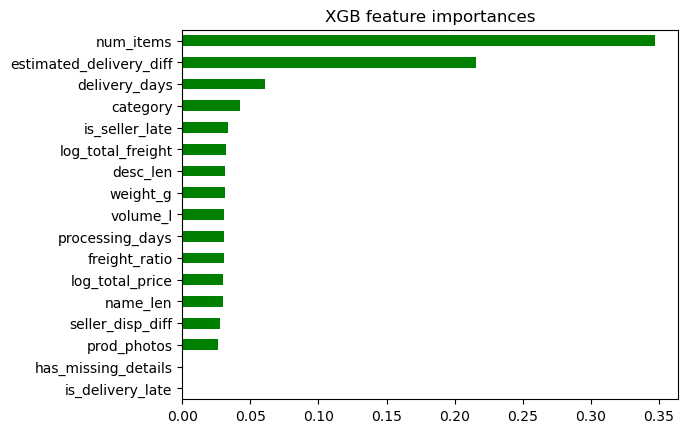

In [11]:
importances_xgb.plot(kind='barh', color='green')
plt.title('XGB feature importances')
plt.show()

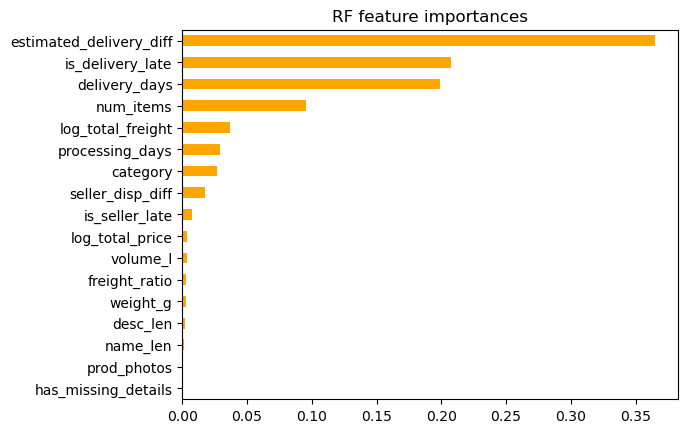

In [14]:
importances_rf.plot(kind='barh', color='orange')
plt.title('RF feature importances')
plt.show()

#### We can see that both dummy estimators rank high the difference between the estimated and the actual delivery time, however the XGB model considers number of items in the order as the most important factor, whereas the RF moel focuses more on the features connected with the delivery times.

Performing Recursive Feature Elimination with Cross Validation - using Stratified KFold due to imbalanced classes. XGB Classifier has been chosen as an estimator.

In [10]:
from src.feature_selection import Selector

selector = Selector(seed=SEED, scale_weight=scale_weight)

In [ ]:
selector.fit(X_train_tr, y_train)

features_to_keep = selector.features_to_keep_
cv_results = selector.cv_results

In [43]:
print('Features to keep: ', list(features_to_keep), '\n')
print('RFE test scores: ', cv_results['mean_test_score'])

Features to keep:  ['num_items', 'desc_len', 'category', 'weight_g', 'delivery_days', 'estimated_delivery_diff', 'log_total_freight'] 

RFE test scores:  [0.37535407 0.43455019 0.44093013 0.44115999 0.4443034  0.43885901
 0.44443925 0.44236019 0.44165813 0.44288168 0.43785968 0.4419122
 0.44238195 0.4402671  0.44000619 0.44000619 0.44000619]


Transforming the train and test sets to reduce the number of features used in proper model training.

In [13]:
X_train_redudced = selector.transform(X_train_tr)
X_test_reduced = selector.transform(X_test_tr)

### **Step 3 - Hyperparameter tuning with Optuna**

In [19]:
from src.model import Model

xgb_model = Model('xgb', SEED)
rf_model = Model('rf', SEED, n_trials=50)

#### Tuning XGB and RF models to compare their final scores and metrics 

In [ ]:
xgb_model.tune_and_fit(X_train_redudced, y_train)

Inspecting best XGB parameters and F1 (study) score

In [21]:
print('Best XGB params: ', xgb_model.best_params_)
print('Best XGB F1 score:', f'{xgb_model.best_score_:.3f}')

Best XGB params:  {'max_depth': 6, 'learning_rate': 0.022267809009867977, 'n_estimators': 325, 'subsample': 0.8521900492040966, 'colsample_bytree': 0.734932237187023, 'min_child_weight': 4, 'gamma': 1.7110378148709928}
Best XGB F1 score: 0.459


In [ ]:
rf_model.tune_and_fit(X_train_redudced, y_train)

Inspecting best RF parameters and F1 (study) score

In [31]:
print('Best RF params: ', rf_model.best_params_)
print('Best RF F1 score:', f'{rf_model.best_score_:.3f}')

Best RF params:  {'max_depth': 10, 'n_estimators': 390, 'min_samples_split': 16, 'min_samples_leaf': 13, 'max_features': 0.4207693426302724}
Best RF F1 score: 0.460


### **Step 4 - Reviewing both models performance on the test set**

In [23]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
#xgb_model.load('best_xgb.pkl')
#rf_model.load('best_rf.pkl')

#xgb_model.fit(X_train_redudced, y_train)
#rf_model.fit(X_train_redudced, y_train)

#### Classification report of the tuned XGB model.

In [ ]:
y_pred_xgb = xgb_model.predict(X_test_reduced)
xgb_report = classification_report(y_test, y_pred_xgb)

print(xgb_report)
print(f'XGB F1 Test score: {f1_score(y_test, y_pred_xgb):.3f}')

              precision    recall  f1-score   support

           0       0.86      0.81      0.83     15128
           1       0.41      0.51      0.46      4034

    accuracy                           0.74     19162
   macro avg       0.64      0.66      0.64     19162
weighted avg       0.77      0.74      0.75     19162

XGB F1 Test score: 0.457


#### Classification report of the tuned RF model.

In [ ]:
y_pred_rf = rf_model.predict(X_test_reduced)
rf_report = classification_report(y_test, y_pred_rf)

print(rf_report)
print(f'RF F1 Test score: {f1_score(y_test, y_pred_rf):.3f}')

              precision    recall  f1-score   support

           0       0.86      0.83      0.85     15128
           1       0.43      0.48      0.45      4034

    accuracy                           0.76     19162
   macro avg       0.65      0.66      0.65     19162
weighted avg       0.77      0.76      0.76     19162

RF F1 Test score: 0.454


#### Both classifiers seem to perform at a very close level (F1 score of ~0.45), which suggest reaching a limit of predicability with this set of features using tree based models. Despite this tie, XGBoost will be used further as the 'main' model for this problem. 

#### Examining feature impact on the model decisions after the hyperparameter-tuning process using SHAP plot.

In [ ]:
import shap

In [52]:
X_val = X_test_reduced.sample(frac=0.2, random_state=SEED)
X_val.shape

(3832, 7)

In [ ]:
explainer = shap.TreeExplainer(xgb_model.best_model_)
shap_values = explainer.shap_values(X_val)

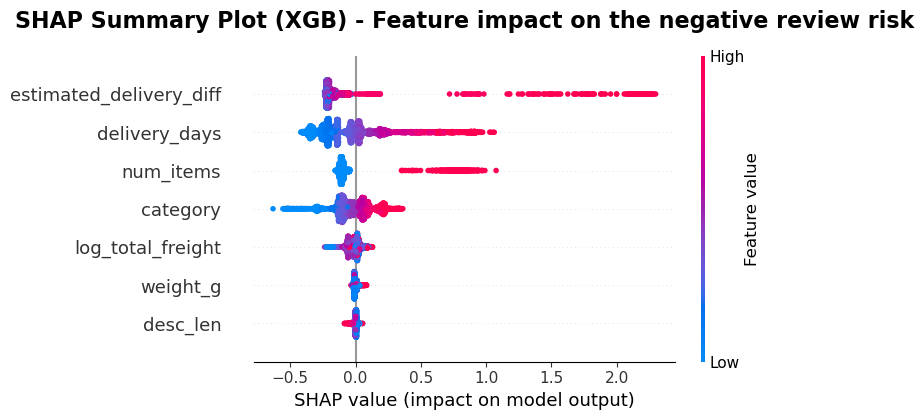

In [ ]:
plt.figure(figsize=(10,6))

shap.summary_plot(shap_values, X_val, show=False)
plt.title('SHAP Summary Plot (XGB) - Feature impact on the negative review risk', fontsize=16, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

### **SHAP** summary plot reveals feature hierarchy as well as impact of each feature on the customer dissatisfaction. The key conclusions are:
1. **estimated_delivery_diff** - massive rightward tail proves that delayed deliveries have strong influence on customer dissatisfaction.

2. **num_items** - single-item orders (blue cluster) are relatively safe. However the moment an order contains multiple items, the SHAP value jumps significantly to the right - orders with 2+ items carry a much higher risk of the customer leaving a negative review.

3. **category** - separation between blue and red clusters proves that our Target Encoder successfully captured the risk of specific product categories.

#### Inspecting the confusion matrix of the XGB classifier

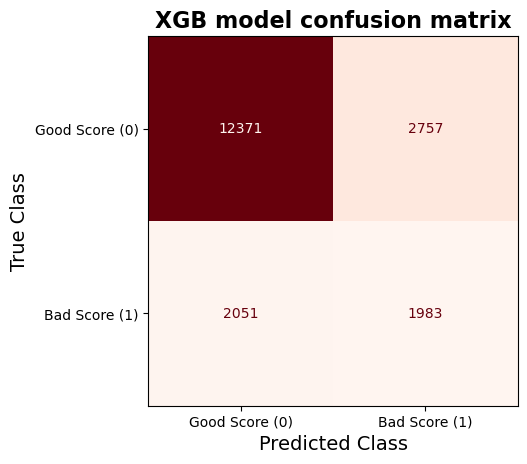

In [68]:
cm = confusion_matrix(y_test, y_pred_xgb)

ConfusionMatrixDisplay(cm, display_labels=['Good Score (0)', 'Bad Score (1)']).plot(cmap='Reds',colorbar=False)

plt.title('XGB model confusion matrix', size=16, fontweight='bold')
plt.ylabel('True Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)

plt.show()

### **Confusion matrix** analysis:
* **True Positives (1,983 correctly predicted negative reviews)** - The model was able to identify nearly 2,000 dissatisfied customers based purely on logistical and order data. The business can make proactive moves (such as apology email, discount codes, etc.) to minimize the risk of a customer **churn**.

* **False Positives (2,757 false alarms)** - The model predicted a negative review, but the customer remained satisfied. Proactive reach out to those customers costs almost nothing and can even boost brand loyalty.

* **True Negatives (12,371 correctly predicted good reviews)** - The model correctly filtered out the majority of seamless transactions.

* **False Negatives (2,051 missed bad reviews)** - These are the customers who left a bad review despite the model predicting a good outcome. This number of mispredictions can be concerning, however many 1-star reviews come from the factors independent of the logistical data, like poor product quality or broken items. Since we are making predictions in a highly subjective area, we must accept the risk of missing the dissatisfied customers.


#### Saving the best models and the trained Target Encoder to the pkl files for further usage in the interactive Streamlit app.

In [28]:
xgb_model.save('best_xgb.pkl')
rf_model.save('best_rf.pkl')
tr.save()

Saved the best XGB model to best_xgb.pkl
Saved the best RF model to best_rf.pkl
Saved the target encoder to target_encoder.pkl
